In [1]:
import torch
import time
import matplotlib.pyplot as plt
from plpm.classes.nn import BaselinePINN
from torch.optim.lr_scheduler import ReduceLROnPlateau
from plpm.scripts_internal.GoverningEqns import GoverningEqns
ODEs = GoverningEqns()
Scaling = ODEs.Scaling
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
mR_av, mR_ao, mC_ao, mR_art, mC_art = torch.tensor([1., 1., 1., 1., 1.])  # Multipliers
mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv = torch.tensor([1., 1., 1., 1., 1.])

CASE = torch.tensor([[mR_av, mR_ao, mC_ao, mR_art, mC_art,
                      mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv]])

sCASE = Scaling.CaseScaler(CASE).to(device)
nt = torch.linspace(0.0, 1.0, 401).reshape((-1, 1)).requires_grad_().to(device)

In [3]:
torch.manual_seed(0)
model = BaselinePINN().to(device)
iteration = 0
learning_rate = 1e-3
opt = torch.optim.Adam(model.parameters(), lr = learning_rate)
scheduler = ReduceLROnPlateau(opt, patience=100, cooldown=100, min_lr=1e-6)

In [4]:
start = time.time()
while iteration < 150000:
    sV_CASE = model(nt)
    opt.zero_grad()
    if opt.param_groups[0]['lr'] > 1.1e-5:
        residuals = ODEs(sCASE, nt, sV_CASE, alpha=0.002)
        loss = torch.mean(torch.abs(residuals))
    else:
        residuals = ODEs(sCASE, nt, sV_CASE, alpha=0.01)
        loss = torch.mean(torch.square(residuals))
    loss.backward(retain_graph=True)
    loss = loss.item()
    iteration += 1
    if (iteration % 5000 == 0):
        print(f"iteration {iteration} | loss: {loss} | lr: {opt.param_groups[0]['lr']}")
    opt.step()
    scheduler.step(loss)

print(f"Total Training Time: {time.time() - start} seconds.")

iteration 5000 | loss: 0.0006048303170841059 | lr: 1e-05
iteration 10000 | loss: 0.00027902962022184917 | lr: 1e-05
iteration 15000 | loss: 8.594184766230687e-05 | lr: 1e-05
iteration 20000 | loss: 5.157856887807423e-05 | lr: 1e-05
iteration 25000 | loss: 4.057538423074801e-05 | lr: 1e-05
iteration 30000 | loss: 3.359706129744022e-05 | lr: 1e-05
iteration 35000 | loss: 2.8291327969000933e-05 | lr: 1e-05
iteration 40000 | loss: 2.3951648071312833e-05 | lr: 1e-05
iteration 45000 | loss: 2.0598824252779818e-05 | lr: 1e-05
iteration 50000 | loss: 1.818117507470186e-05 | lr: 1e-05
iteration 55000 | loss: 1.6315016487443466e-05 | lr: 1e-05
iteration 60000 | loss: 1.4955802166892964e-05 | lr: 1e-05
iteration 65000 | loss: 1.3780282981128409e-05 | lr: 1e-05
iteration 70000 | loss: 1.3424146853171056e-05 | lr: 1e-05
iteration 75000 | loss: 1.2030834632314928e-05 | lr: 1e-05
iteration 80000 | loss: 1.1343802891924118e-05 | lr: 1e-05
iteration 85000 | loss: 1.072591313884759e-05 | lr: 1e-05
itera

Steady State Solution
Elapsed Time:  4.848028659820557 seconds


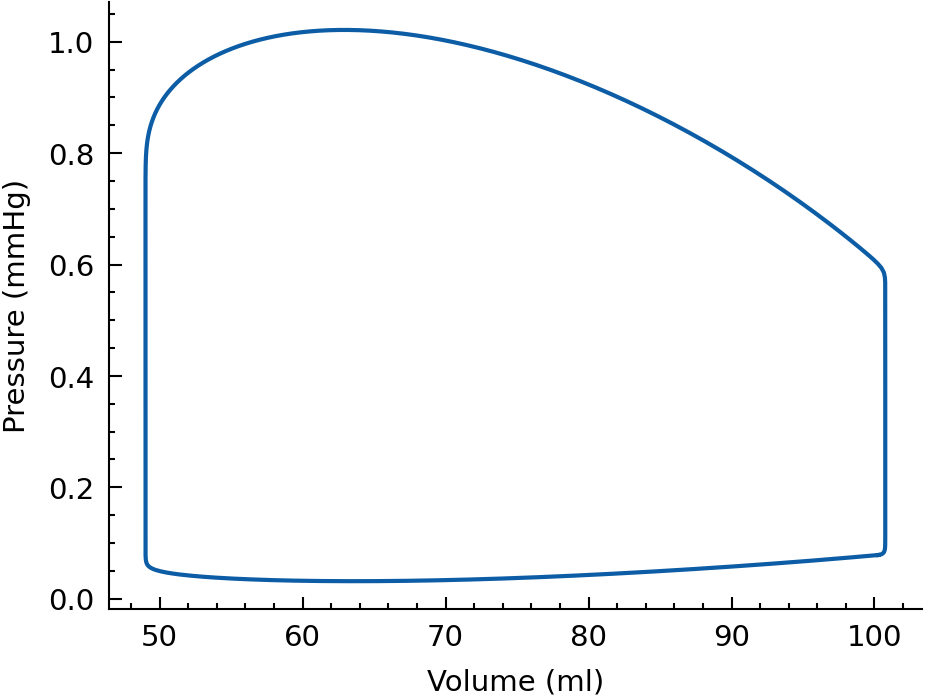

In [5]:
# Solving numerically
from plpm import numerical_solver, calculate_PLV

V_numerical = numerical_solver(CASE, n_cycle=30)
P_lv = calculate_PLV(V_numerical[:, 0])

fig, ax = plt.subplots()
ax.plot(V_numerical[:, 0], P_lv * 0.0075)
ax.set_xlabel('Volume (ml)')
ax.set_ylabel('Pressure (mmHg)')
plt.show()

In [6]:
sV_CASE = model(nt).detach().cpu()
V_pinn = Scaling.InvVolScaler(sV_CASE)

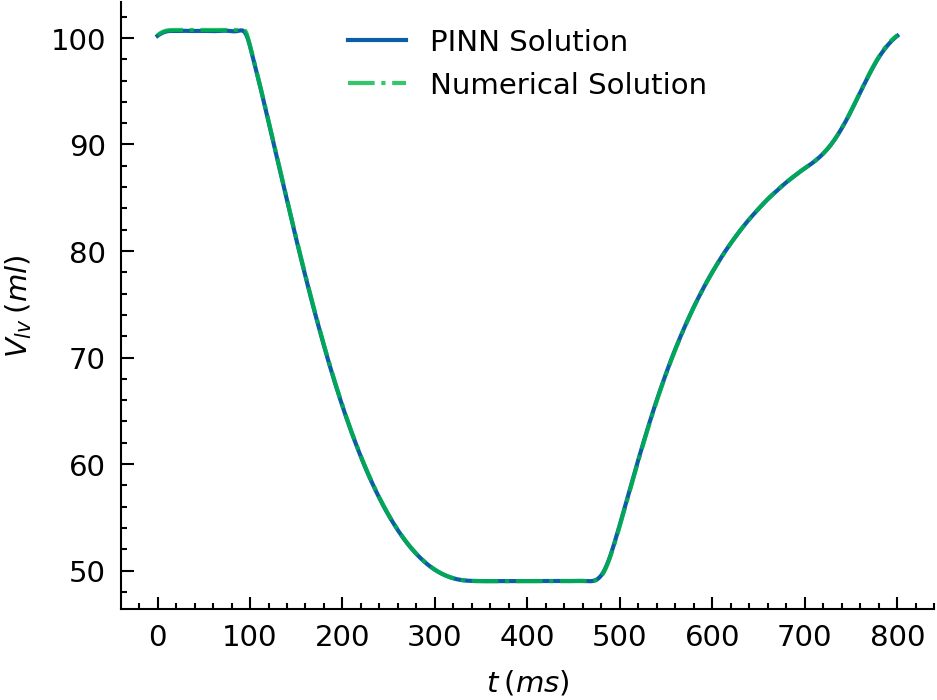

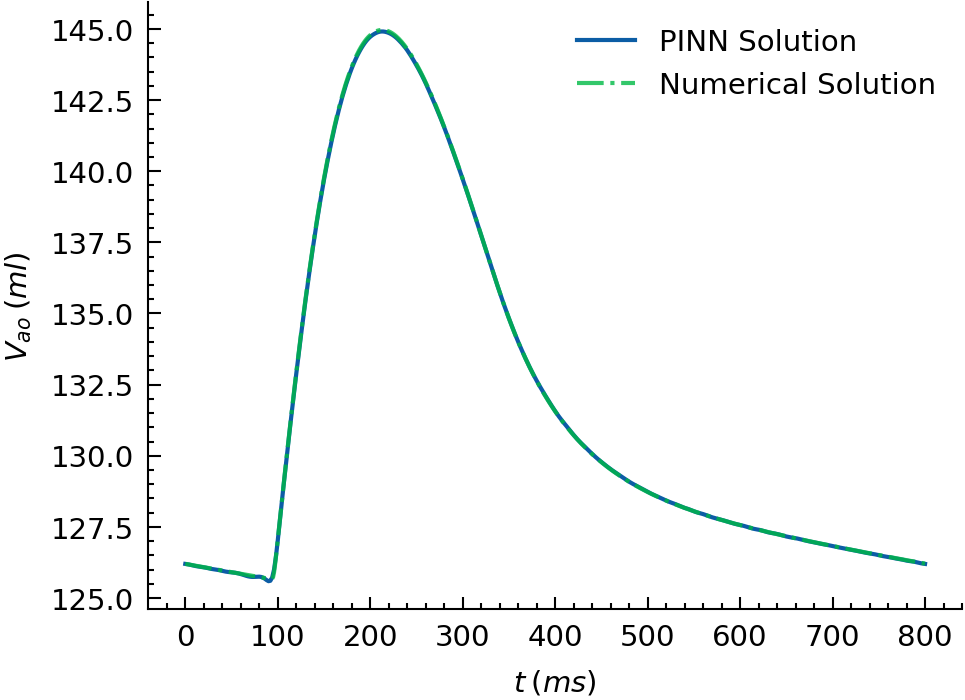

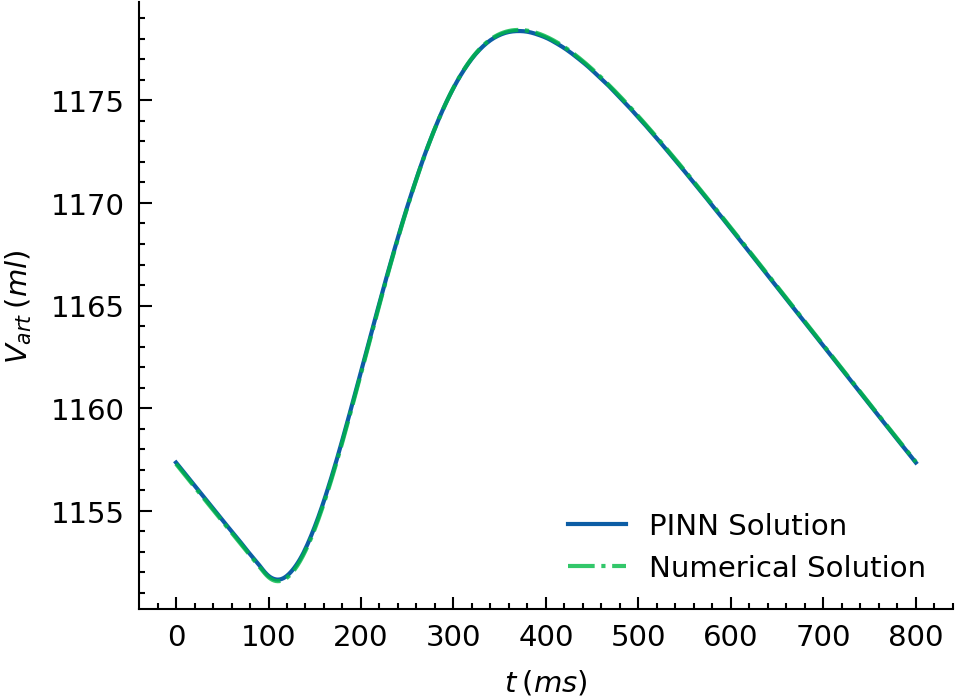

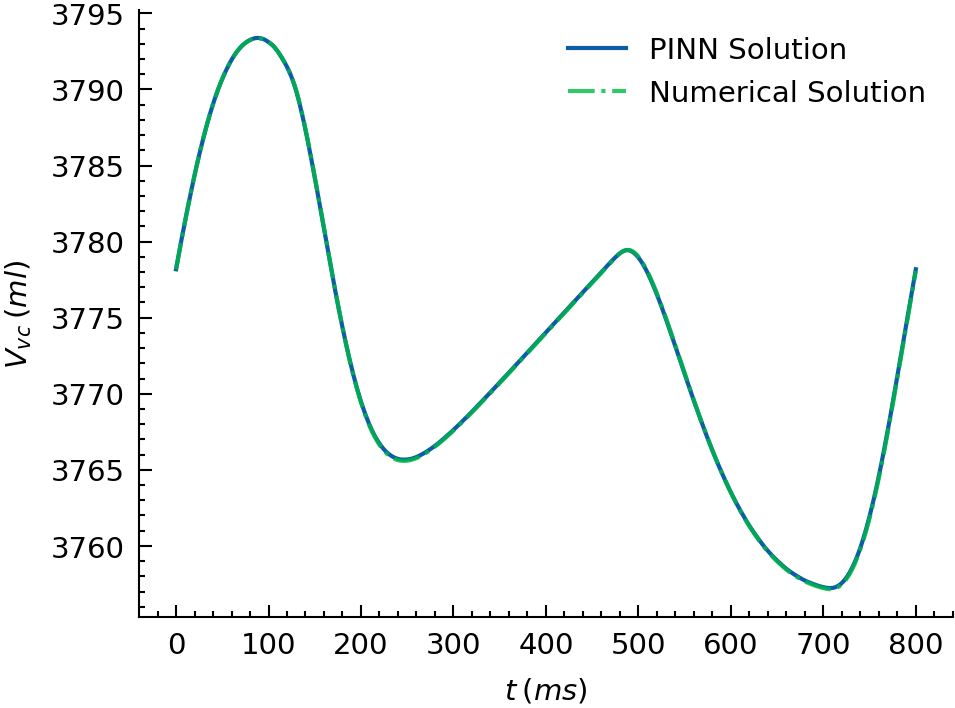

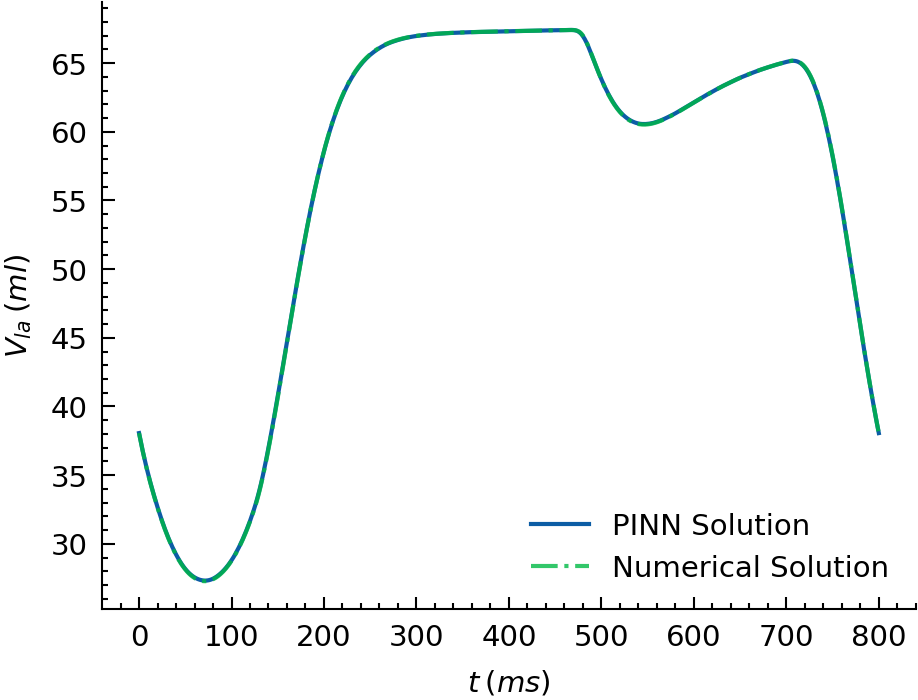

In [7]:
from plpm import MainPlots
figures = MainPlots()
figures.plot_CASE_seperate(V_pinn=V_pinn, V_numerical=V_numerical)

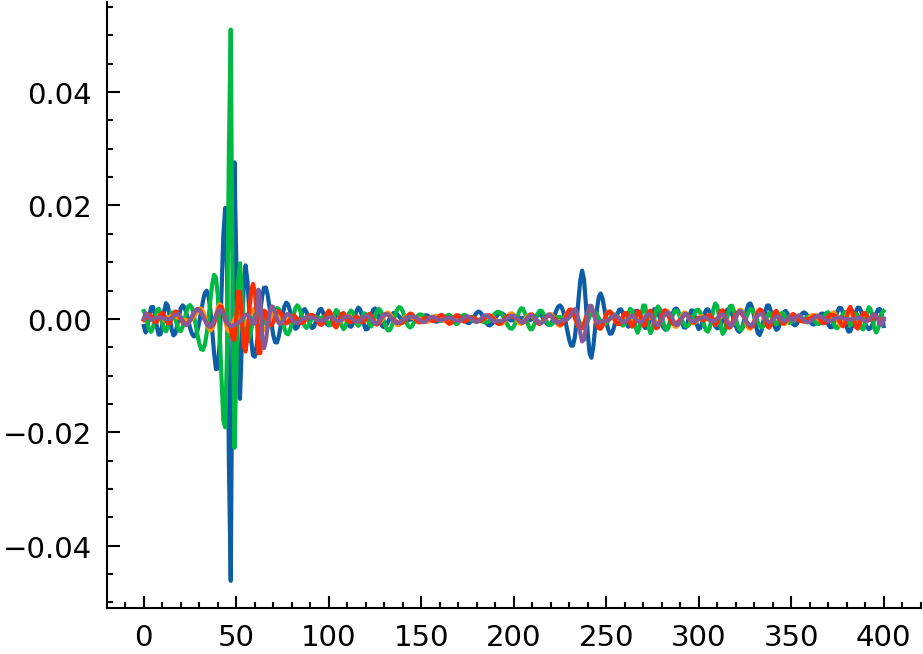

In [13]:
sV_CASE = model(nt)
residuals = ODEs(sCASE, nt, sV_CASE).detach().cpu()

plt.plot(residuals[:, 0])
plt.plot(residuals[:, 1])
plt.plot(residuals[:, 2])
plt.plot(residuals[:, 3])
plt.plot(residuals[:, 4])

In [14]:
snapshot = {
    "EPOCHS_RUN": iteration,
    "MODEL_STATE": model.state_dict(),
    "OPTIMIZER": opt.state_dict(),
    "SCHEDULER": scheduler.state_dict(),
}
torch.save(snapshot, "../models/model/baselineModel.pt")